# Customer Churn Prediction — Optuna Hyperparameter Tuning

**Goal:** Find better LightGBM hyperparameters using Optuna's Bayesian optimisation.

LightGBM won notebook 03 by AUC-PR. Default hyperparameters leave performance on the table —  
Optuna searches the space efficiently using a Tree-structured Parzen Estimator (TPE).

**Inputs:** Processed train/test splits from `02_feature_engineering.ipynb`

---
**Notebook structure:**
1. Setup
2. Load data and rebuild preprocessor
3. Define the Optuna objective
4. Run optimisation study
5. Analyse study results
6. Retrain with best params and compare to default
7. Save tuned model + log to MLflow

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import optuna

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    classification_report
)
import lightgbm as lgb

# Suppress Optuna's per-trial log output — show only the final summary
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../reports/figures')
MODELS_DIR    = Path('../saved_models')

print('Libraries loaded.  Optuna version:', optuna.__version__)

Libraries loaded.  Optuna version: 4.9.0


## 1. Load Data and Rebuild Preprocessor

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape}  |  churn rate: {y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape}   |  churn rate: {y_test.mean()*100:.1f}%')

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Train: (5634, 24)  |  churn rate: 26.5%
Test : (1409, 24)   |  churn rate: 26.5%
scale_pos_weight: 2.77


In [3]:
# Rebuild preprocessor from scratch — same reason as notebook 03:
# pickle-loaded transformers cannot be cloned across CV worker processes.
NUM_COLS = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'total_services', 'charge_per_service',
    'has_security', 'is_long_contract'
]
CAT_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'tenure_group'
]

def build_preprocessor():
    """Return a fresh ColumnTransformer — called inside each trial."""
    num_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, NUM_COLS),
        ('cat', cat_pipe, CAT_COLS),
    ], remainder='drop')

print('Preprocessor factory ready.')

Preprocessor factory ready.


## 2. Define the Optuna Objective

Optuna calls `objective(trial)` repeatedly.  
Each call samples a hyperparameter set, runs 5-fold CV, and returns the mean AUC-PR.  
Optuna uses TPE to focus future trials on regions that produced high scores.

In [4]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    # Search space — ranges chosen from LightGBM docs and empirical defaults
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators',      100, 1000, step=50),
        'learning_rate'    : trial.suggest_float('learning_rate',    0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves',         20, 300),
        'max_depth'        : trial.suggest_int('max_depth',          3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples',  5, 100),
        'subsample'        : trial.suggest_float('subsample',        0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha',        1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda',       1e-8, 10.0, log=True),
        'scale_pos_weight' : scale_pos_weight,
        'random_state'     : 42,
        'n_jobs'           : 1,   # keep single-process inside CV
        'verbose'          : -1,
    }

    pipeline = Pipeline([
        ('prep',  build_preprocessor()),
        ('model', lgb.LGBMClassifier(**params)),
    ])

    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=CV,
        scoring='average_precision',
        n_jobs=1,
        error_score='raise'
    )
    return scores.mean()

print('Objective function defined.')

Objective function defined.


## 3. Run Optimisation Study

In [5]:
N_TRIALS = 50  # increase to 100+ for a longer search in production

study = optuna.create_study(
    direction='maximize',
    study_name='lgb_churn_aucpr',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
)

print(f'Starting Optuna study — {N_TRIALS} trials, maximising AUC-PR ...')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest AUC-PR : {study.best_value:.4f}')
print('Best params :')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Starting Optuna study — 50 trials, maximising AUC-PR ...


  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC-PR : 0.6676
Best params :
  n_estimators: 550
  learning_rate: 0.01799695641090977
  num_leaves: 77
  max_depth: 3
  min_child_samples: 93
  subsample: 0.9495057082956689
  colsample_bytree: 0.5903248584058137
  reg_alpha: 7.0471770375876635e-06
  reg_lambda: 0.05129444895701995


## 4. Analyse Study Results

In [6]:
# Full trial history
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=False)
print(f'Top 5 trials:')
display_cols = ['number', 'value'] + [c for c in trials_df.columns if c.startswith('params_')]
trials_df[display_cols].head(5).round(4)

Top 5 trials:


,number,value,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_n_estimators,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample
35,35,0.6676,0.5903,0.0180,3,93,550,77,0.0,0.0513,0.9495
47,47,0.6674,0.9220,0.0116,4,12,700,54,0.0,0.3036,0.9540
36,36,0.6674,0.7359,0.0127,3,91,800,81,0.0,0.9854,0.9994
43,43,0.6672,0.7671,0.0123,3,14,750,22,0.0,3.0415,0.8849
38,38,0.6670,0.7550,0.0124,3,14,800,75,0.0,1.8533,0.9676


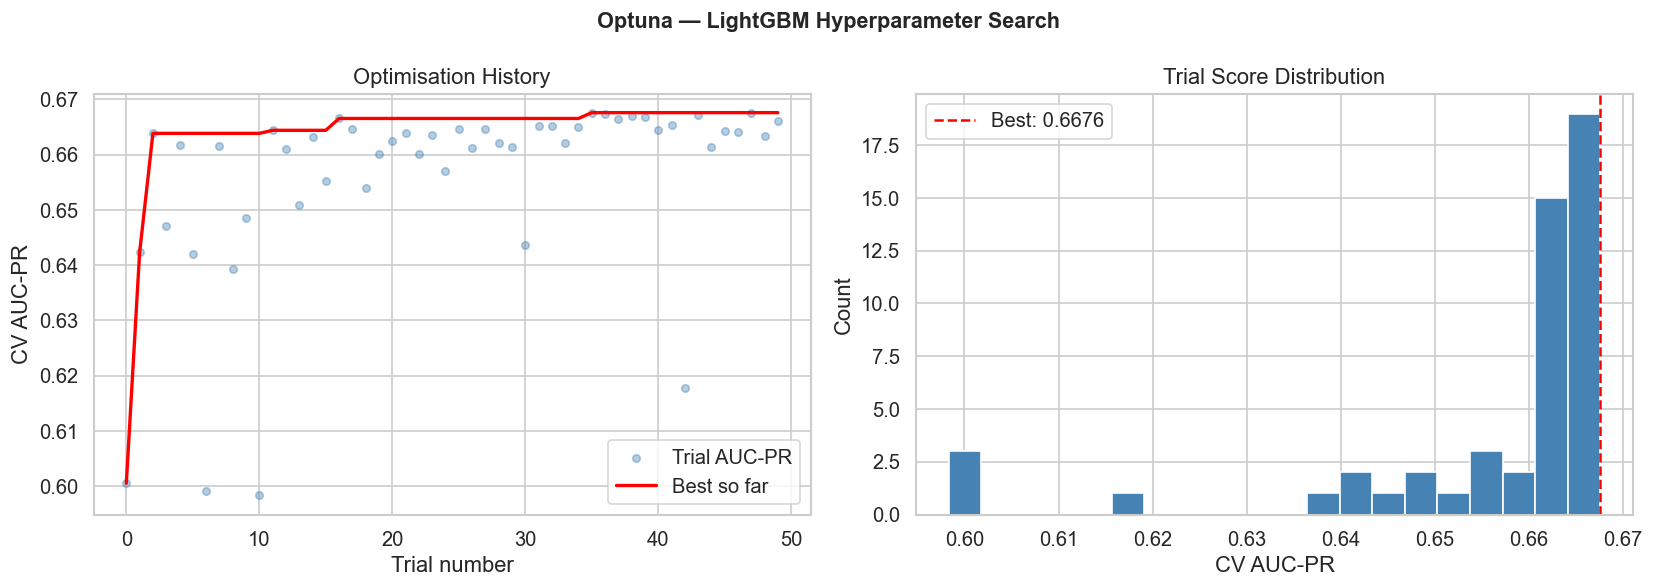

In [7]:
# Optimisation history — shows how AUC-PR improved over trials
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial values over time
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = pd.Series(trial_values).cummax()

axes[0].scatter(range(len(trial_values)), trial_values,
                alpha=0.4, s=20, color='steelblue', label='Trial AUC-PR')
axes[0].plot(best_so_far, color='red', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial number')
axes[0].set_ylabel('CV AUC-PR')
axes[0].set_title('Optimisation History')
axes[0].legend()

# AUC-PR distribution across trials
axes[1].hist(trial_values, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(study.best_value, color='red', linestyle='--',
                linewidth=1.5, label=f'Best: {study.best_value:.4f}')
axes[1].set_xlabel('CV AUC-PR')
axes[1].set_ylabel('Count')
axes[1].set_title('Trial Score Distribution')
axes[1].legend()

plt.suptitle('Optuna — LightGBM Hyperparameter Search', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '24_optuna_history.png', dpi=150)
plt.show()

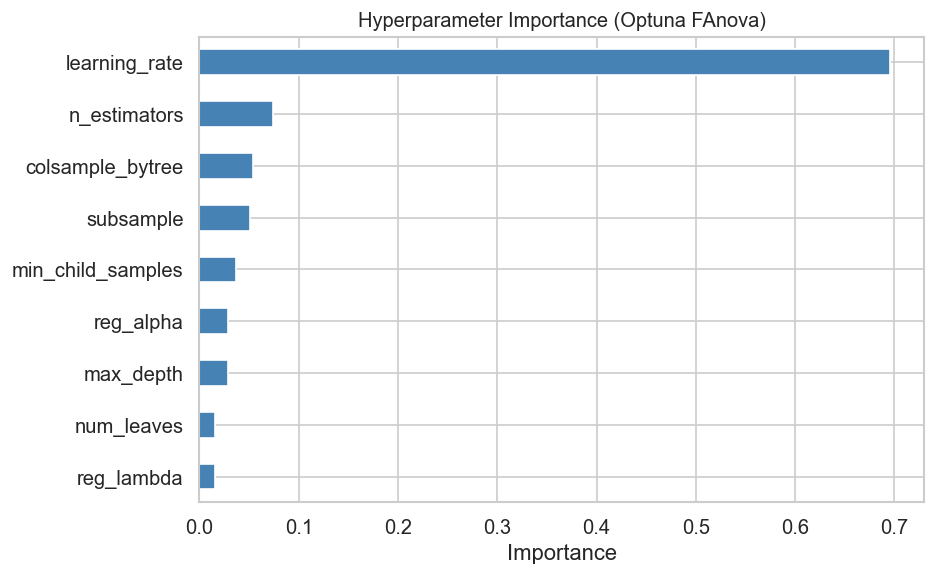

Most impactful parameter: learning_rate


In [8]:
# Parameter importance — which hyperparameters had the most impact
importance = optuna.importance.get_param_importances(study)

importance_series = pd.Series(importance).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importance_series.plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Hyperparameter Importance (Optuna FAnova)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '25_param_importance.png', dpi=150)
plt.show()

print('Most impactful parameter:', importance_series.index[-1])

## 5. Retrain with Best Params and Compare to Default

In [9]:
# Default LightGBM — same config used in notebook 03
default_pipeline = Pipeline([
    ('prep',  build_preprocessor()),
    ('model', lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )),
])

# Tuned LightGBM — Optuna best params
tuned_pipeline = Pipeline([
    ('prep',  build_preprocessor()),
    ('model', lgb.LGBMClassifier(
        **study.best_params,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )),
])

print('Fitting default LightGBM ...')
default_pipeline.fit(X_train, y_train)
default_proba = default_pipeline.predict_proba(X_test)[:, 1]

print('Fitting tuned LightGBM ...')
tuned_pipeline.fit(X_train, y_train)
tuned_proba = tuned_pipeline.predict_proba(X_test)[:, 1]

# Metrics
results = {
    'Default LightGBM': {
        'roc_auc': roc_auc_score(y_test, default_proba),
        'auc_pr' : average_precision_score(y_test, default_proba),
    },
    'Tuned LightGBM (Optuna)': {
        'roc_auc': roc_auc_score(y_test, tuned_proba),
        'auc_pr' : average_precision_score(y_test, tuned_proba),
    },
}

results_df = pd.DataFrame(results).T.round(4)
print('\n=== Test Set Comparison ===')
print(results_df.to_string())

Fitting default LightGBM ...


Fitting tuned LightGBM ...



=== Test Set Comparison ===
                         roc_auc  auc_pr
Default LightGBM          0.8295  0.6357
Tuned LightGBM (Optuna)   0.8474  0.6678


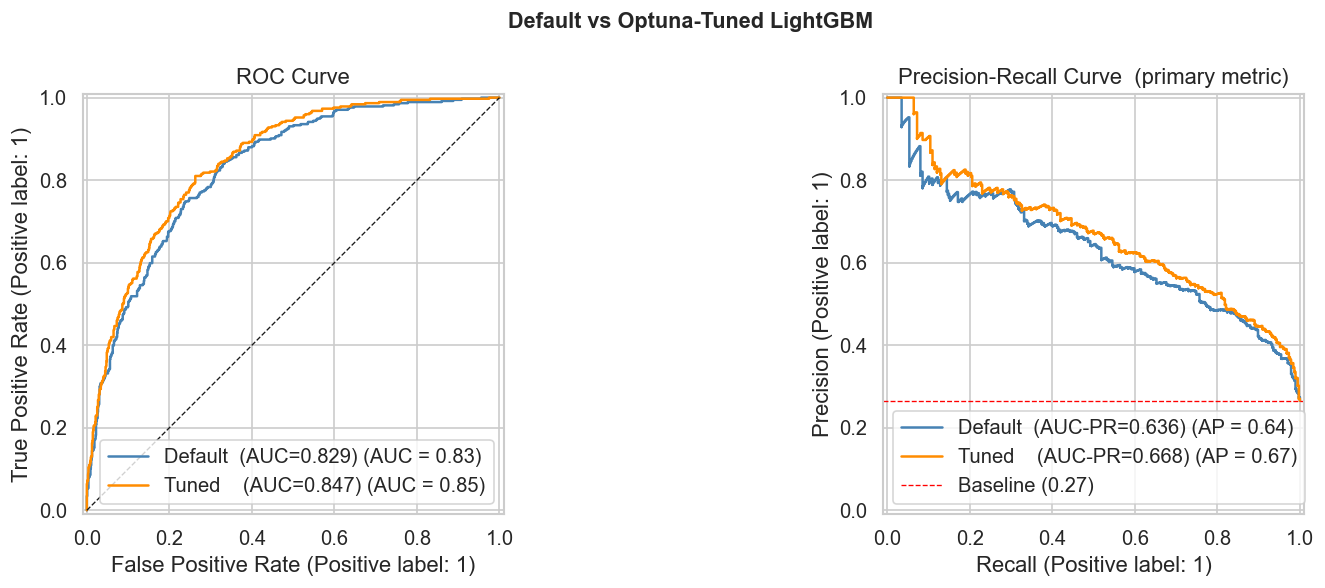

In [10]:
# Side-by-side ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test, default_proba,
    name=f'Default  (AUC={results["Default LightGBM"]["roc_auc"]:.3f})',
    ax=axes[0], color='steelblue'
)
RocCurveDisplay.from_predictions(
    y_test, tuned_proba,
    name=f'Tuned    (AUC={results["Tuned LightGBM (Optuna)"]["roc_auc"]:.3f})',
    ax=axes[0], color='darkorange'
)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(
    y_test, default_proba,
    name=f'Default  (AUC-PR={results["Default LightGBM"]["auc_pr"]:.3f})',
    ax=axes[1], color='steelblue'
)
PrecisionRecallDisplay.from_predictions(
    y_test, tuned_proba,
    name=f'Tuned    (AUC-PR={results["Tuned LightGBM (Optuna)"]["auc_pr"]:.3f})',
    ax=axes[1], color='darkorange'
)
baseline = y_test.mean()
axes[1].axhline(baseline, color='red', linestyle='--',
                linewidth=0.8, label=f'Baseline ({baseline:.2f})')
axes[1].set_title('Precision-Recall Curve  (primary metric)')
axes[1].legend()

plt.suptitle('Default vs Optuna-Tuned LightGBM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '26_tuned_vs_default.png', dpi=150)
plt.show()

In [11]:
# Print lift from tuning
default_aucpr = results['Default LightGBM']['auc_pr']
tuned_aucpr   = results['Tuned LightGBM (Optuna)']['auc_pr']
lift_pct      = (tuned_aucpr - default_aucpr) / default_aucpr * 100

print(f'Default AUC-PR : {default_aucpr:.4f}')
print(f'Tuned AUC-PR   : {tuned_aucpr:.4f}')
print(f'Lift           : {lift_pct:+.1f}%')

Default AUC-PR : 0.6357
Tuned AUC-PR   : 0.6678
Lift           : +5.1%


## 6. Save Tuned Model + Log to MLflow

In [12]:
mlflow.set_experiment('customer-churn-prediction')

with mlflow.start_run(run_name='LightGBM_optuna_tuned'):
    # Log best Optuna params
    mlflow.log_params(study.best_params)
    mlflow.log_param('n_trials', N_TRIALS)
    mlflow.log_param('optuna_best_cv_aucpr', round(study.best_value, 4))

    # Log test metrics
    mlflow.log_metrics({
        'test_roc_auc': round(results['Tuned LightGBM (Optuna)']['roc_auc'], 4),
        'test_auc_pr' : round(results['Tuned LightGBM (Optuna)']['auc_pr'],  4),
    })

    # Log model
    mlflow.sklearn.log_model(tuned_pipeline, 'churn_pipeline_tuned')

    # Log figures from this notebook
    for fig_name in ['24_optuna_history.png', '25_param_importance.png', '26_tuned_vs_default.png']:
        mlflow.log_artifact(str(FIGURES_DIR / fig_name), artifact_path='figures')

    run_id = mlflow.active_run().info.run_id

print(f'MLflow run logged. Run ID: {run_id}')

2026/06/14 15:28:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/14 15:28:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged. Run ID: acf451965ae9424aa3fad19c63a66c9f


In [13]:
# Save as a separate pickle so the original model is preserved
tuned_path = MODELS_DIR / 'churn_pipeline_tuned.pkl'
with open(tuned_path, 'wb') as f:
    pickle.dump(tuned_pipeline, f)

print(f'Tuned model saved to : {tuned_path}')
print(f'File size            : {tuned_path.stat().st_size / 1024:.1f} KB')

Tuned model saved to : ../saved_models/churn_pipeline_tuned.pkl
File size            : 525.1 KB


## Summary

In [14]:
print(f"""
=== OPTUNA TUNING SUMMARY ===

SEARCH:
  Trials          : {N_TRIALS}
  Sampler         : TPE (Tree-structured Parzen Estimator)
  Objective       : 5-fold CV AUC-PR (maximise)
  Best CV AUC-PR  : {study.best_value:.4f}

TEST SET RESULTS:
  Default LightGBM        AUC-PR: {default_aucpr:.4f}   ROC-AUC: {results['Default LightGBM']['roc_auc']:.4f}
  Tuned LightGBM (Optuna) AUC-PR: {tuned_aucpr:.4f}   ROC-AUC: {results['Tuned LightGBM (Optuna)']['roc_auc']:.4f}
  AUC-PR lift     : {lift_pct:+.1f}%

BEST PARAMS:
  {chr(10).join(f'  {k}: {v}' for k, v in study.best_params.items())}

ARTIFACTS SAVED:
  saved_models/churn_pipeline_tuned.pkl
  reports/figures/24_optuna_history.png
  reports/figures/25_param_importance.png
  reports/figures/26_tuned_vs_default.png
  MLflow run: {run_id}

NEXT STEP:
  06_generalization.ipynb — apply the same pipeline to a second churn dataset.
""")


=== OPTUNA TUNING SUMMARY ===

SEARCH:
  Trials          : 50
  Sampler         : TPE (Tree-structured Parzen Estimator)
  Objective       : 5-fold CV AUC-PR (maximise)
  Best CV AUC-PR  : 0.6676

TEST SET RESULTS:
  Default LightGBM        AUC-PR: 0.6357   ROC-AUC: 0.8295
  Tuned LightGBM (Optuna) AUC-PR: 0.6678   ROC-AUC: 0.8474
  AUC-PR lift     : +5.1%

BEST PARAMS:
    n_estimators: 550
  learning_rate: 0.01799695641090977
  num_leaves: 77
  max_depth: 3
  min_child_samples: 93
  subsample: 0.9495057082956689
  colsample_bytree: 0.5903248584058137
  reg_alpha: 7.0471770375876635e-06
  reg_lambda: 0.05129444895701995

ARTIFACTS SAVED:
  saved_models/churn_pipeline_tuned.pkl
  reports/figures/24_optuna_history.png
  reports/figures/25_param_importance.png
  reports/figures/26_tuned_vs_default.png
  MLflow run: acf451965ae9424aa3fad19c63a66c9f

NEXT STEP:
  06_generalization.ipynb — apply the same pipeline to a second churn dataset.

